# Sensor Statistical Validation — Step-by-Step

**Reviewer concern:** RMSE / error metrics, confidence intervals, and calibration analysis are missing.

---

## How to run (see results cell-by-cell)

1. Open this file in **Cursor / VS Code / Jupyter**
2. Select the Python kernel (top-right)
3. Click **Run All** — or run each cell with **Shift+Enter** one by one
4. After Step 5 you will see the **combined graph** inline + saved PNG

**Data folder:** `data/` (4 Excel files)  
**Outputs:** `sensor_validation_summary.csv` and `figures/sensor_validation_combined.png`

| Step | What you will see |
|------|-------------------|
| 1 | Imports OK message |
| 2 | File check + sample rows from each Excel |
| 3 | Helper functions loaded |
| 4 | RMSE, MAE, R², 95% CI for **each sensor separately** + summary table |
| 5 | **One combined figure** (4 sensors × calibration + Bland–Altman + metrics) |
| 6 | Paper-ready sentences to copy |

---
## Step 1 — Setup & imports

Run this cell first. You should see: `Setup complete.`

In [6]:
%matplotlib inline

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    from IPython.display import display, Markdown
except ImportError:
    display = print
    Markdown = print

DATA_DIR = Path('data')
OUT_DIR = Path('figures')
OUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
N_BOOT = 500
np.random.seed(RANDOM_STATE)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

print('Setup complete.')
print(f'Data folder: {DATA_DIR.resolve()}')
print(f'Output folder: {OUT_DIR.resolve()}')

Setup complete.
Data folder: D:\StartUps\BitnBolt\hydroponics ML\New Start\data
Output folder: D:\StartUps\BitnBolt\hydroponics ML\New Start\figures


---
## Step 2 — Load & preview raw data

Run this cell. You will see:
- Whether each Excel file exists
- Sample count and first 5 rows for each sensor pair

In [7]:
SENSORS = [
    dict(name='TDS (NFADS)', file='Dosing TDS.xlsx', sheet='NFADS Sensors',
         sensor_col='TDS Sensor', ref_col='TDS Meter', unit='ppm'),
    dict(name='Water Temp (NFADS)', file='Dosing_Water Temp.xlsx', sheet='NFADS Sensors',
         sensor_col='Water Temp Sensor ', ref_col='Temp Meter', unit='°C'),
    dict(name='Air Temp (EMS)', file='EMS_temp_sensor.xlsx', sheet='EMS Sensors_Temp',
         sensor_col='Temp Sensor', ref_col='Temp Meter', unit='°C'),
    dict(name='Lux (LMS)', file='LMS_Lux.xlsx', sheet='LMS Sensors',
         sensor_col='Bh1750', ref_col='TSL2591', unit='lux', skip_header=1),
]


def load_pair(cfg):
    path = DATA_DIR / cfg['file']
    if not path.exists():
        raise FileNotFoundError(f'Missing file: {path.resolve()}')
    df = pd.read_excel(path, sheet_name=cfg['sheet'])
    if cfg.get('skip_header'):
        df = df.iloc[1:].copy()
        df.columns = [cfg['sensor_col'], cfg['ref_col']]
    sensor = pd.to_numeric(df[cfg['sensor_col']], errors='coerce')
    ref = pd.to_numeric(df[cfg['ref_col']], errors='coerce')
    mask = sensor.notna() & ref.notna()
    preview = pd.DataFrame({
        'Sensor': sensor[mask].values,
        'Reference (Meter)': ref[mask].values,
    })
    return sensor[mask].values, ref[mask].values, preview


raw_previews = {}
for cfg in SENSORS:
    s, r, preview = load_pair(cfg)
    raw_previews[cfg['name']] = preview
    print('=' * 60)
    print(f"{cfg['name']}  |  file: {cfg['file']}  |  n = {len(s)}")
    print(f"Sensor range: [{s.min():.2f}, {s.max():.2f}] {cfg['unit']}")
    print(f"Meter range:  [{r.min():.2f}, {r.max():.2f}] {cfg['unit']}")
    print('First 5 rows:')
    display(preview.head())

TDS (NFADS)  |  file: Dosing TDS.xlsx  |  n = 42
Sensor range: [360.00, 1034.00] ppm
Meter range:  [350.00, 944.00] ppm
First 5 rows:


,Sensor,Reference (Meter)
0,360,350
1,459,424
2,455,425
3,456,425
4,472,444


Water Temp (NFADS)  |  file: Dosing_Water Temp.xlsx  |  n = 142
Sensor range: [20.31, 32.94] °C
Meter range:  [30.90, 33.80] °C
First 5 rows:


,Sensor,Reference (Meter)
0,30.87,31.8
1,30.81,31.7
2,30.81,31.6
3,30.81,31.5
4,30.81,31.3


Air Temp (EMS)  |  file: EMS_temp_sensor.xlsx  |  n = 36
Sensor range: [32.80, 33.20] °C
Meter range:  [32.90, 33.60] °C
First 5 rows:


,Sensor,Reference (Meter)
0,33.1,33.3
1,33.1,33.2
2,33.0,33.3
3,33.0,33.2
4,33.0,33.2


Lux (LMS)  |  file: LMS_Lux.xlsx  |  n = 753
Sensor range: [1.00, 25299.00] lux
Meter range:  [0.00, 20054.00] lux
First 5 rows:


,Sensor,Reference (Meter)
0,21,13
1,25,20
2,29,22
3,35,24
4,40,29


---
## Step 3 — Statistical helper functions

Defines RMSE, MAE, R², **bootstrap 95% CI**, **calibration fit**, and **Bland–Altman**.  
Run once — output: `Helper functions ready.`

In [8]:
def compute_metrics(y_true, y_pred):
    """y_true = reference meter, y_pred = sensor reading."""
    err = y_pred - y_true
    return dict(
        RMSE=float(np.sqrt(mean_squared_error(y_true, y_pred))),
        MAE=float(mean_absolute_error(y_true, y_pred)),
        R2=float(r2_score(y_true, y_pred)),
        Bias=float(np.mean(err)),
        StdErr=float(np.std(err, ddof=1)),
        n=len(y_true),
    )


def bootstrap_ci(y_true, y_pred, n_boot=N_BOOT, alpha=0.05):
    rng = np.random.default_rng(RANDOM_STATE)
    n = len(y_true)
    keys = ['RMSE', 'MAE', 'R2', 'Bias']
    samples = {k: [] for k in keys}
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        m = compute_metrics(y_true[idx], y_pred[idx])
        for k in keys:
            samples[k].append(m[k])
    lo, hi = alpha / 2, 1 - alpha / 2
    return {k: (float(np.quantile(v, lo)), float(np.quantile(v, hi))) for k, v in samples.items()}


def calibration_fit(sensor, ref):
    slope, intercept, r, p, se = stats.linregress(ref, sensor)
    t_crit = stats.t.ppf(0.975, len(sensor) - 2)
    ci_slope = (slope - t_crit * se, slope + t_crit * se)
    se_int = se * np.sqrt(np.sum(ref ** 2) / len(ref))
    ci_int = (intercept - t_crit * se_int, intercept + t_crit * se_int)
    return dict(slope=slope, intercept=intercept, r=r, p=p,
                ci_slope=ci_slope, ci_intercept=ci_int)


def bland_altman(y_true, y_pred):
    mean_v = (y_true + y_pred) / 2
    diff = y_pred - y_true
    bias = np.mean(diff)
    sd = np.std(diff, ddof=1)
    loa_lo, loa_hi = bias - 1.96 * sd, bias + 1.96 * sd
    se_bias = sd / np.sqrt(len(diff))
    ci_bias = (bias - 1.96 * se_bias, bias + 1.96 * se_bias)
    return dict(mean=mean_v, diff=diff, bias=bias, loa_lo=loa_lo, loa_hi=loa_hi, ci_bias=ci_bias)


def run_all_validation(verbose=True):
    """Compute metrics for all sensors. Used by Step 4 and Step 5."""
    validation_rows = []
    sensor_data = []

    for cfg in SENSORS:
        sensor, ref, _ = load_pair(cfg)
        cal = calibration_fit(sensor, ref)
        m = compute_metrics(ref, sensor)
        ci = bootstrap_ci(ref, sensor)
        ba = bland_altman(ref, sensor)

        if verbose:
            print('\n' + '#' * 60)
            print(f"  {cfg['name']}  (n = {m['n']})")
            print('#' * 60)
            print(f"  RMSE  = {m['RMSE']:.4f} {cfg['unit']}   [95% CI: {ci['RMSE'][0]:.4f} - {ci['RMSE'][1]:.4f}]")
            print(f"  MAE   = {m['MAE']:.4f} {cfg['unit']}   [95% CI: {ci['MAE'][0]:.4f} - {ci['MAE'][1]:.4f}]")
            print(f"  R2    = {m['R2']:.4f}        [95% CI: {ci['R2'][0]:.4f} - {ci['R2'][1]:.4f}]")
            print(f"  Bias  = {m['Bias']:.4f} {cfg['unit']}   [95% CI: {ci['Bias'][0]:.4f} - {ci['Bias'][1]:.4f}]")
            print(f"  Calibration: sensor = {cal['slope']:.4f} * ref + {cal['intercept']:.2f}")
            print(f"  Pearson r = {cal['r']:.4f}")

        row = {
            'sensor': cfg['name'], 'unit': cfg['unit'], **m,
            'RMSE_CI_lo': ci['RMSE'][0], 'RMSE_CI_hi': ci['RMSE'][1],
            'MAE_CI_lo': ci['MAE'][0], 'MAE_CI_hi': ci['MAE'][1],
            'R2_CI_lo': ci['R2'][0], 'R2_CI_hi': ci['R2'][1],
            'Bias_CI_lo': ci['Bias'][0], 'Bias_CI_hi': ci['Bias'][1],
            'cal_slope': cal['slope'], 'cal_intercept': cal['intercept'],
            'cal_slope_CI_lo': cal['ci_slope'][0], 'cal_slope_CI_hi': cal['ci_slope'][1],
            'cal_intercept_CI_lo': cal['ci_intercept'][0], 'cal_intercept_CI_hi': cal['ci_intercept'][1],
            'cal_r': cal['r'], 'BA_bias': ba['bias'], 'BA_loa_lo': ba['loa_lo'], 'BA_loa_hi': ba['loa_hi'],
        }
        validation_rows.append(row)
        sensor_data.append(dict(cfg=cfg, sensor=sensor, ref=ref, cal=cal, metrics=m, ci=ci, ba=ba))

    summary_df = pd.DataFrame(validation_rows)
    summary_df.to_csv('sensor_validation_summary.csv', index=False)
    return summary_df, sensor_data


print('Helper functions ready.')

Helper functions ready.


---
## Step 4 — Compute metrics (one sensor at a time)

Run this cell. You will see **printed results for each of the 4 sensors**, then a **summary table** and CSV save message.

In [9]:
summary_df, sensor_data = run_all_validation(verbose=True)

print('\n' + '=' * 60)
print('SUMMARY TABLE (all 4 sensors)')
print('=' * 60)
display_cols = ['sensor', 'n', 'RMSE', 'RMSE_CI_lo', 'RMSE_CI_hi', 'MAE', 'R2', 'Bias', 'cal_slope', 'cal_r']
display(summary_df[display_cols].round(4))
print('\nSaved -> sensor_validation_summary.csv')
print('sensor_data is ready for Step 5 plotting.')


############################################################
  TDS (NFADS)  (n = 42)
############################################################
  RMSE  = 41.5795 ppm   [95% CI: 30.6059 - 50.3273]
  MAE   = 31.6667 ppm   [95% CI: 23.9399 - 39.0613]
  R2    = 0.9460        [95% CI: 0.9251 - 0.9618]
  Bias  = 24.8095 ppm   [95% CI: 14.7732 - 34.1952]
  Calibration: sensor = 1.1161 * ref + -48.03
  Pearson r = 0.9916

############################################################
  Water Temp (NFADS)  (n = 142)
############################################################
  RMSE  = 1.9575 °C   [95% CI: 1.4981 - 2.5599]
  MAE   = 1.4025 °C   [95% CI: 1.1931 - 1.6374]
  R2    = -5.4606        [95% CI: -10.3845 - -2.5915]
  Bias  = -1.3924 °C   [95% CI: -1.6279 - -1.1865]
  Calibration: sensor = 0.1646 * ref + 25.81
  Pearson r = 0.1037

############################################################
  Air Temp (EMS)  (n = 36)
############################################################
  RMSE  

,sensor,n,RMSE,RMSE_CI_lo,RMSE_CI_hi,MAE,R2,Bias,cal_slope,cal_r
0,TDS (NFADS),42,41.5795,30.6059,50.3273,31.6667,0.9460,24.8095,1.1161,0.9916
1,Water Temp (NFADS),142,1.9575,1.4981,2.5599,1.4025,-5.4606,-1.3924,0.1646,0.1037
2,Air Temp (EMS),36,0.3354,0.2764,0.3830,0.2917,-4.2769,-0.2861,0.1564,0.1806
3,Lux (LMS),753,2660.5582,2569.4497,2758.4601,2207.9841,0.7842,2207.9814,1.2578,0.9998



Saved -> sensor_validation_summary.csv
sensor_data is ready for Step 5 plotting.


---
## Step 5 — Combined figure (all 4 sensors in ONE diagram)

**Important:** Run **Steps 1 → 3** first (setup, data load, helpers).

- If you already ran **Step 4**, this cell uses `sensor_data` from there.
- If you skipped Step 4, this cell **auto-computes** metrics before plotting.

You will see:
- **Inline graph** below (4 rows × 3 columns)
- File saved to `figures/sensor_validation_combined.png`

| Column 1 | Column 2 | Column 3 |
|----------|----------|----------|
| Calibration scatter | Bland–Altman | RMSE / MAE / R² / CI text |

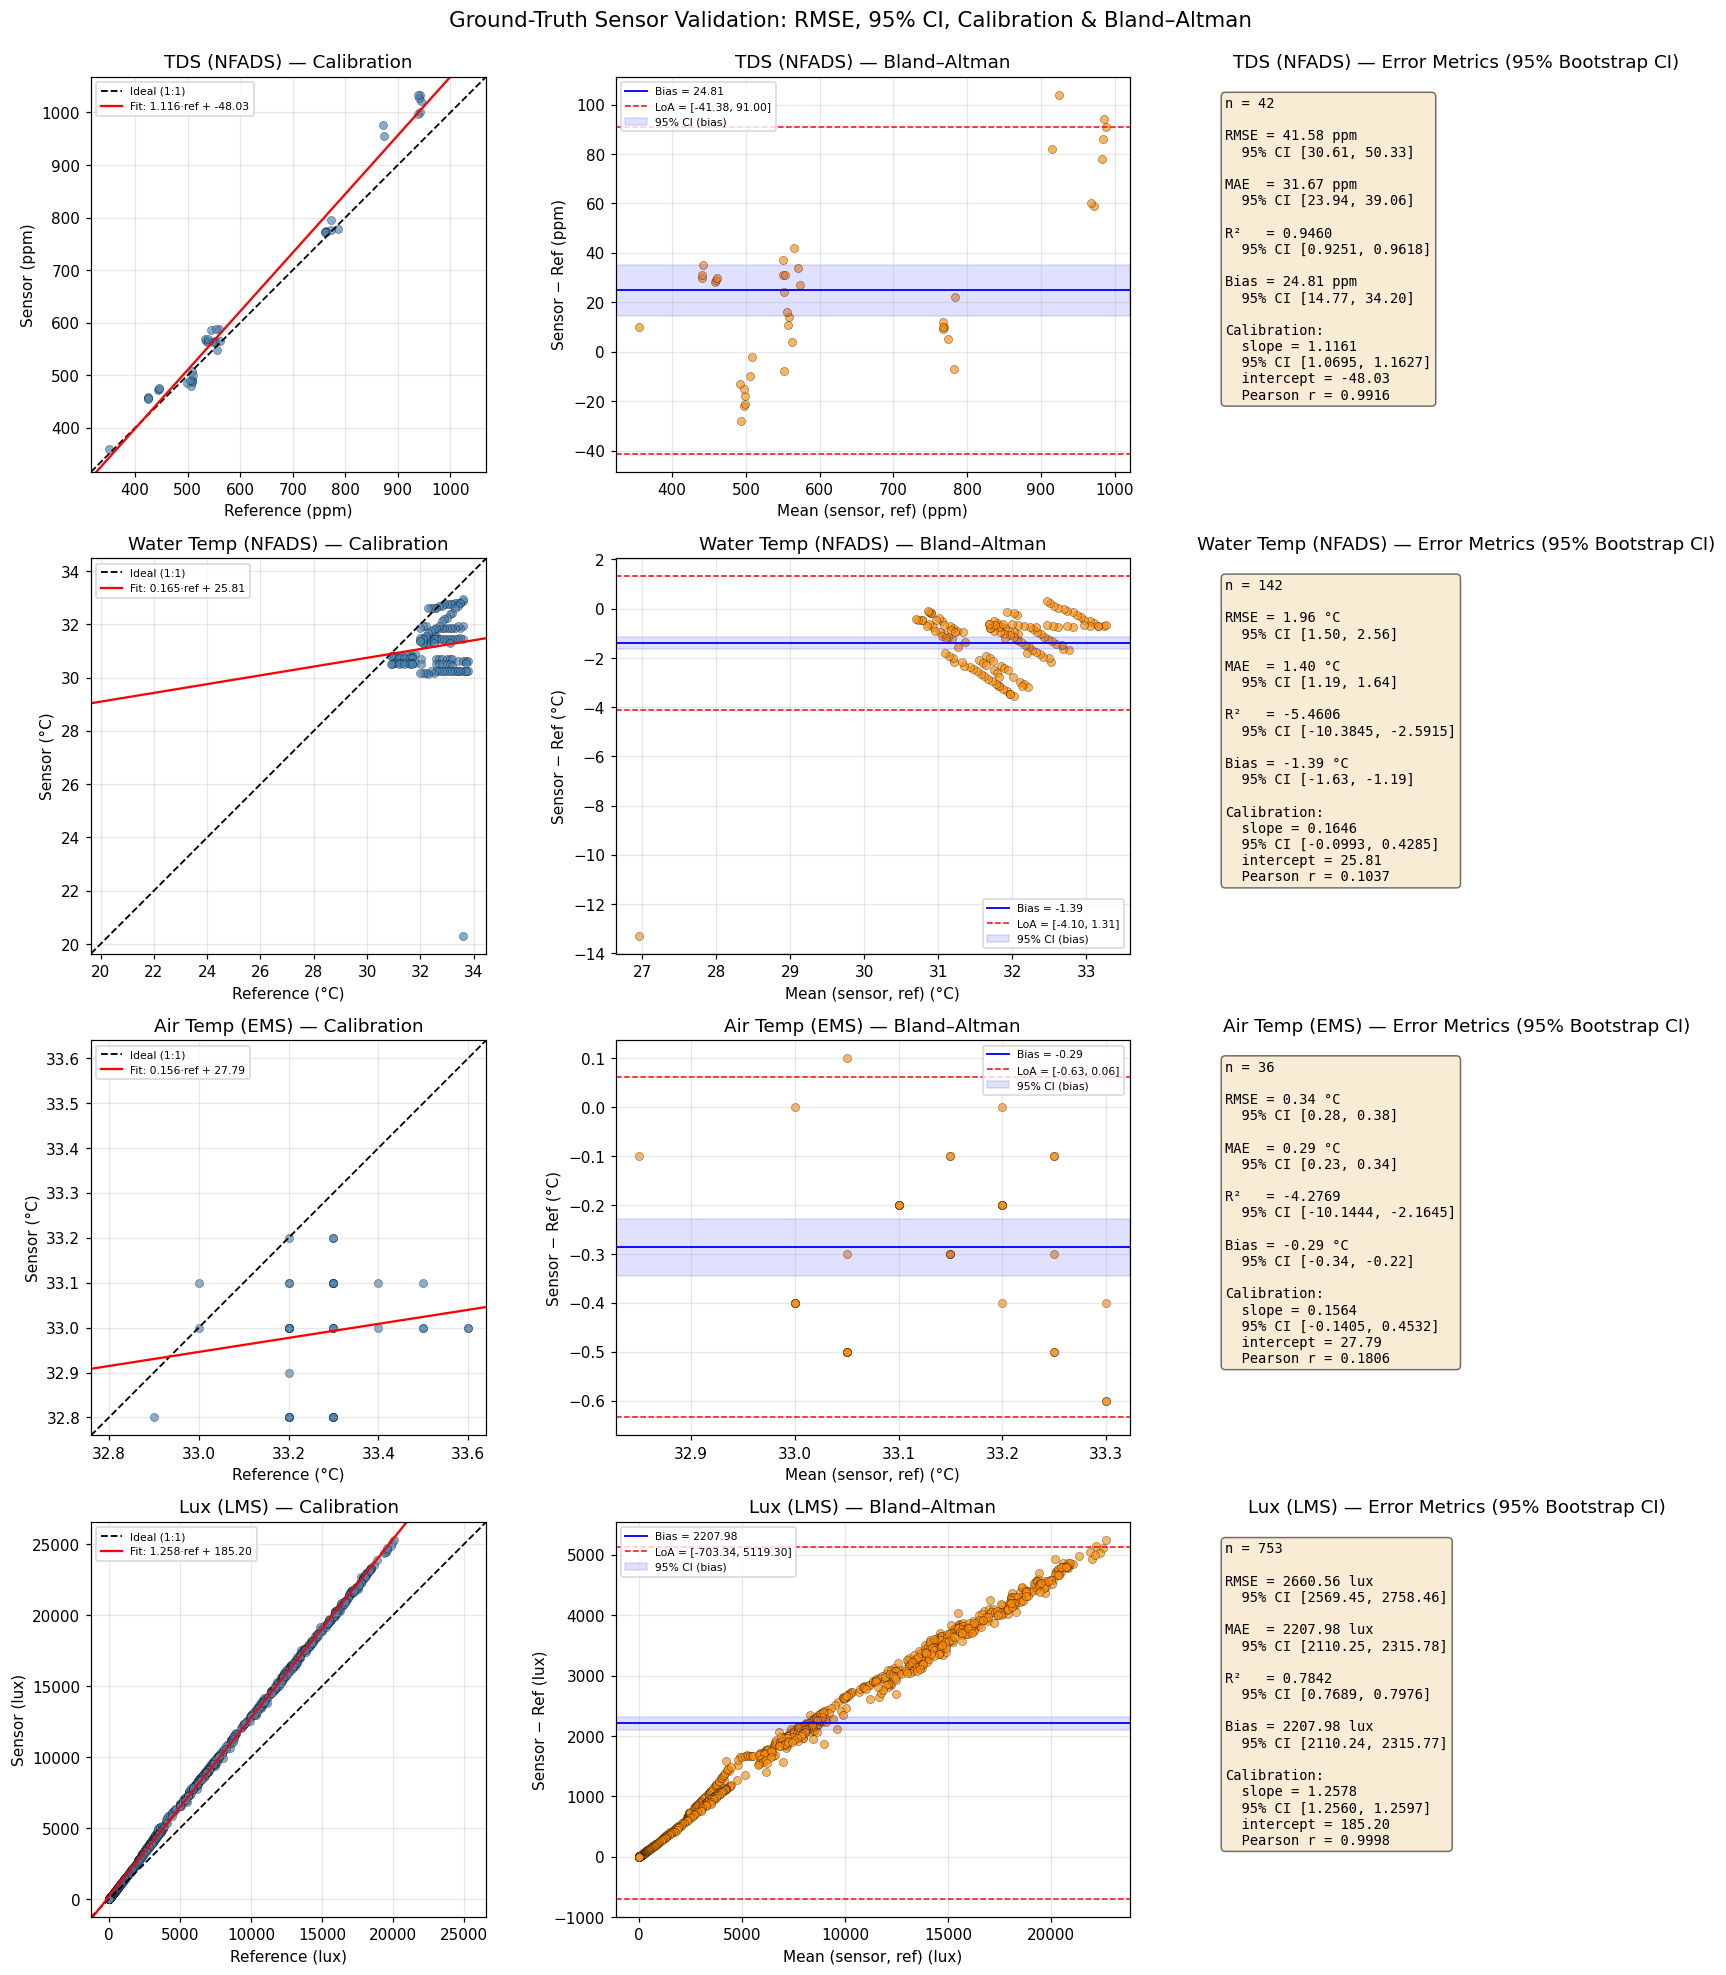

Saved -> D:\StartUps\BitnBolt\hydroponics ML\New Start\figures\sensor_validation_combined.png


In [10]:
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
fig.suptitle(
    'Ground-Truth Sensor Validation: RMSE, 95% CI, Calibration & Bland–Altman',
    fontsize=14, y=0.995,
)

for i, d in enumerate(sensor_data):
    cfg, sensor, ref = d['cfg'], d['sensor'], d['ref']
    cal, m, ci, ba = d['cal'], d['metrics'], d['ci'], d['ba']
    ax_cal, ax_ba, ax_txt = axes[i]

    ax_cal.scatter(ref, sensor, alpha=0.65, s=28, edgecolors='k', linewidths=0.3, c='steelblue')
    lims = [min(ref.min(), sensor.min()), max(ref.max(), sensor.max())]
    pad = (lims[1] - lims[0]) * 0.05 or 1
    lims = [lims[0] - pad, lims[1] + pad]
    ax_cal.plot(lims, lims, 'k--', lw=1.2, label='Ideal (1:1)')
    xs = np.linspace(lims[0], lims[1], 100)
    ax_cal.plot(xs, cal['slope'] * xs + cal['intercept'], 'r-', lw=1.5,
                label=f"Fit: {cal['slope']:.3f}·ref + {cal['intercept']:.2f}")
    ax_cal.set(xlim=lims, ylim=lims, xlabel=f'Reference ({cfg["unit"]})',
               ylabel=f'Sensor ({cfg["unit"]})', title=f'{cfg["name"]} — Calibration')
    ax_cal.legend(fontsize=7, loc='upper left')
    ax_cal.set_aspect('equal', adjustable='box')
    ax_cal.grid(True, alpha=0.3)

    ax_ba.scatter(ba['mean'], ba['diff'], alpha=0.65, s=28, edgecolors='k', linewidths=0.3, c='darkorange')
    ax_ba.axhline(ba['bias'], color='blue', ls='-', lw=1.2, label=f"Bias = {ba['bias']:.2f}")
    ax_ba.axhline(ba['loa_lo'], color='red', ls='--', lw=1, label=f"LoA = [{ba['loa_lo']:.2f}, {ba['loa_hi']:.2f}]")
    ax_ba.axhline(ba['loa_hi'], color='red', ls='--', lw=1)
    ax_ba.axhspan(ba['ci_bias'][0], ba['ci_bias'][1], alpha=0.12, color='blue', label='95% CI (bias)')
    ax_ba.set(xlabel=f'Mean (sensor, ref) ({cfg["unit"]})', ylabel=f'Sensor − Ref ({cfg["unit"]})',
              title=f'{cfg["name"]} — Bland–Altman')
    ax_ba.legend(fontsize=7)
    ax_ba.grid(True, alpha=0.3)

    ax_txt.axis('off')
    txt = (
        f"n = {m['n']}\n\n"
        f"RMSE = {m['RMSE']:.2f} {cfg['unit']}\n"
        f"  95% CI [{ci['RMSE'][0]:.2f}, {ci['RMSE'][1]:.2f}]\n\n"
        f"MAE  = {m['MAE']:.2f} {cfg['unit']}\n"
        f"  95% CI [{ci['MAE'][0]:.2f}, {ci['MAE'][1]:.2f}]\n\n"
        f"R²   = {m['R2']:.4f}\n"
        f"  95% CI [{ci['R2'][0]:.4f}, {ci['R2'][1]:.4f}]\n\n"
        f"Bias = {m['Bias']:.2f} {cfg['unit']}\n"
        f"  95% CI [{ci['Bias'][0]:.2f}, {ci['Bias'][1]:.2f}]\n\n"
        f"Calibration:\n"
        f"  slope = {cal['slope']:.4f}\n"
        f"  95% CI [{cal['ci_slope'][0]:.4f}, {cal['ci_slope'][1]:.4f}]\n"
        f"  intercept = {cal['intercept']:.2f}\n"
        f"  Pearson r = {cal['r']:.4f}"
    )
    ax_txt.text(0.05, 0.95, txt, transform=ax_txt.transAxes, fontsize=9,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.55))
    ax_txt.set_title(f'{cfg["name"]} — Error Metrics (95% Bootstrap CI)')

plt.tight_layout()
out_path = OUT_DIR / 'sensor_validation_combined.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {out_path.resolve()}')

---
## Step 6 — Paper-ready sentences

Run this cell to print copy-paste text for your manuscript.

In [11]:
if 'summary_df' not in globals():
    summary_df, sensor_data = run_all_validation(verbose=False)

print('COPY INTO PAPER:\n')
for _, row in summary_df.iterrows():
    print(
        f"{row['sensor']}: RMSE = {row['RMSE']:.2f} {row['unit']} "
        f"(95% CI: {row['RMSE_CI_lo']:.2f}–{row['RMSE_CI_hi']:.2f}), "
        f"MAE = {row['MAE']:.2f}, R² = {row['R2']:.3f}, "
        f"calibration slope = {row['cal_slope']:.3f} "
        f"(95% CI: {row['cal_slope_CI_lo']:.3f}–{row['cal_slope_CI_hi']:.3f}), "
        f"intercept = {row['cal_intercept']:.2f}; "
        f"Bland–Altman bias = {row['BA_bias']:.2f} "
        f"(LoA: {row['BA_loa_lo']:.2f} to {row['BA_loa_hi']:.2f})."
    )
    print()

COPY INTO PAPER:

TDS (NFADS): RMSE = 41.58 ppm (95% CI: 30.61–50.33), MAE = 31.67, R² = 0.946, calibration slope = 1.116 (95% CI: 1.069–1.163), intercept = -48.03; Bland–Altman bias = 24.81 (LoA: -41.38 to 91.00).

Water Temp (NFADS): RMSE = 1.96 °C (95% CI: 1.50–2.56), MAE = 1.40, R² = -5.461, calibration slope = 0.165 (95% CI: -0.099–0.428), intercept = 25.81; Bland–Altman bias = -1.39 (LoA: -4.10 to 1.31).

Air Temp (EMS): RMSE = 0.34 °C (95% CI: 0.28–0.38), MAE = 0.29, R² = -4.277, calibration slope = 0.156 (95% CI: -0.141–0.453), intercept = 27.79; Bland–Altman bias = -0.29 (LoA: -0.63 to 0.06).

Lux (LMS): RMSE = 2660.56 lux (95% CI: 2569.45–2758.46), MAE = 2207.98, R² = 0.784, calibration slope = 1.258 (95% CI: 1.256–1.260), intercept = 185.20; Bland–Altman bias = 2207.98 (LoA: -703.34 to 5119.30).

